In [1]:
import os
import yaml
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# Class Distribution analysis

In [10]:
dataset_path = 'vid_full'
train_labels_path = os.path.join(dataset_path, 'train', 'labels')
val_labels_path = os.path.join(dataset_path, 'val', 'labels')


In [11]:
with open(os.path.join(dataset_path, 'data.yaml'), 'r') as f:
    data = yaml.safe_load(f)
    class_names = data['names']

In [12]:
class_names

['person',
 'bicycle',
 'car',
 'motorbike',
 'bus',
 'train',
 'truck',
 'boat',
 'traffic_light',
 'bicycler',
 'braille_block',
 'guardrail',
 'white_line',
 'crosswalk',
 'signal_button',
 'signal_red',
 'signal_blue',
 'stairs',
 'handrail',
 'steps',
 'faregates',
 'train_ticket_machine',
 'shrubs',
 'tree',
 'vending_machine',
 'bathroom',
 'door',
 'elevator',
 'escalator',
 'bollard',
 'bus_stop_sign',
 'pole',
 'monument',
 'fence',
 'wall',
 'signboard',
 'flag',
 'postbox',
 'safety-cone']

In [13]:
def count_classes(directory):
    counter = Counter()

    files = [f for f in os.listdir(directory) if f.endswith('.txt')]

    for file in files:
        file_path = os.path.join(directory, file)
        try:
            with open(file_path, 'r') as f:
                lines = f.readlines()
                
            for line in lines:
                parts = line.strip().split()
                if len(parts)>= 5:
                    class_id = int(parts[0])
                    counter[class_id] += 1
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    return counter

In [14]:
train_counter = count_classes(train_labels_path)
val_counter = count_classes(val_labels_path)

total_counter = train_counter + val_counter
class_counts = {class_names[class_id]: count for class_id, count in total_counter.items()}

sorted_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

In [15]:
for class_name, count in sorted_counts.items():
    print(f"{class_name}: {count}")

steps: 68894
braille_block: 58923
shrubs: 53249
wall: 42472
pole: 41398
car: 37593
fence: 32805
guardrail: 28292
white_line: 28215
person: 25283
tree: 24066
crosswalk: 17586
bollard: 14534
signboard: 5066
safety-cone: 4695
flag: 4416
bicycler: 4237
handrail: 3434
truck: 3416
bicycle: 3321
traffic_light: 3239
stairs: 2801
signal_red: 2218
signal_blue: 1576
motorbike: 1461
vending_machine: 1110
bus: 1109
door: 856
signal_button: 804
faregates: 680
postbox: 574
bus_stop_sign: 571
monument: 532
train: 489
elevator: 65
escalator: 55
bathroom: 43
train_ticket_machine: 20


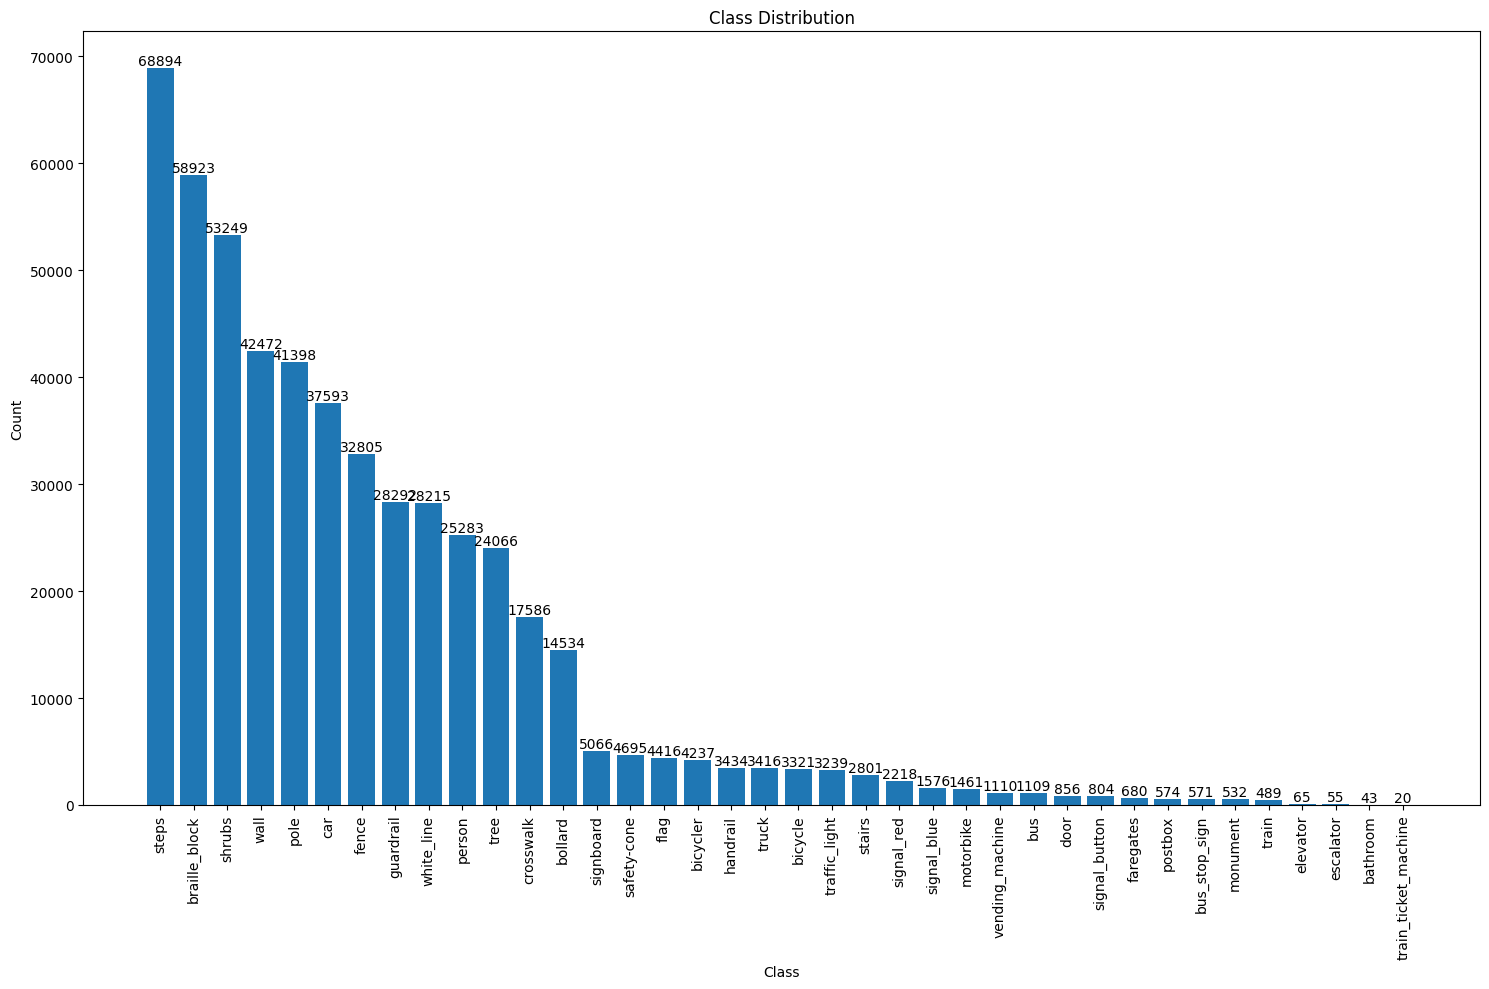

In [16]:
plt.figure(figsize=(15, 10))
bars = plt.bar(sorted_counts.keys(), sorted_counts.values())

plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, int(height), ha='center', va='bottom')

plt.show()


# Analysis of the classes

In [20]:
import yaml
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from torchvision import models, transforms
from sklearn.manifold import TSNE
from PIL import Image
import torch.nn as nn
import supervision as sv

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cpu')

In [22]:
model = models.efficientnet_b0(weights='DEFAULT')
model.classifier = nn.Identity()
model = model.to(device)
model.eval()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/jorgea/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:04<00:00, 4.98MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [23]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [30]:
dataset_path = '/home/jorgea/Code/School/TerminalProject/vid_full'
with open(os.path.join(dataset_path, 'data.yaml')) as f:
    data = yaml.load(f, Loader=yaml.FullLoader)
    class_names = data['names']

In [31]:
def extract_features(img, xyxy):
    x1, y1, x2, y2 = map(int, xyxy)
    if x2 <= x1 or y2 <= y1 or x1 < 0 or y1 < 0:
        return None
    
    h, w = img.shape[:2]
    x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w, x2), min(h, y2)
    
    crop = img[y1:y2, x1:x2]
    if crop.size == 0 or crop.shape[0] < 5 or crop.shape[1] < 5:
        return None

    crop_pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))

    crop_tensor = preprocess(crop_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        features = model(crop_tensor)
        
    return features.cpu().numpy().flatten()

In [36]:
def collect_features(split_dir, max_samples_per_class=50):
    features_list = []
    labels_list = []
    class_counters = {i: 0 for i in range(len(class_names))}
    
    dataset_directory = os.path.join(dataset_path, split_dir)
    
    dataset = sv.DetectionDataset.from_yolo(
        images_directory_path=os.path.join(dataset_directory, 'images'),
        annotations_directory_path=os.path.join(dataset_directory, 'labels'),
        data_yaml_path=os.path.join(dataset_path, 'data.yaml')
    )
    
    # Manera correcta de iterar sobre un DetectionDataset
    for i in tqdm(range(len(dataset)), desc=f"Processing {split_dir}"):
        # Obtener imagen y anotaciones por separado
        image = dataset.images[i]
        annotations = dataset.annotations[i]
        
        # Leer la imagen
        img = cv2.imread(image)
        if img is None:
            continue
            
        # Procesar cada detección en las anotaciones
        for detection in annotations:
            class_id = detection.class_id
            
            # Limitar muestras por clase
            if class_counters[class_id] >= max_samples_per_class:
                continue
            
            # Extraer coordenadas del bounding box
            xyxy = detection.xyxy
            
            # Extraer características
            features = extract_features(img, xyxy)
            if features is not None:
                features_list.append(features)
                labels_list.append(class_id)
                class_counters[class_id] += 1
    
    # Informar sobre las muestras recolectadas
    print(f"Muestras recolectadas por clase en {split_dir}:")
    for class_id, count in class_counters.items():
        if count > 0:
            print(f"  {class_names[class_id]}: {count} muestras")
    
    return np.array(features_list), np.array(labels_list)

In [ ]:
print('Feature extraction initialized')
train_features, train_labels = collect_features('train')
val_features, val_labels = collect_features('val')

train_features, val_features

Feature extraction initialized


Processing train:   0%|          | 0/24377 [00:00<?, ?it/s]SupervisionWarnings: images is deprecated: `DetectionDataset.images` property is deprecated and will be removed in `supervision-0.26.0`. Iterate with `for path, image, annotation in dataset:` instead.
